## Clustering

Example notebook clustering with K-Means and Agglomerative Clustering
* decide on the number of clusters

Ricardo Almeida

In [8]:
from scipy.cluster.hierarchy import dendrogram, linkage
from matplotlib import pyplot as plt
from matplotlib.patches import Ellipse
import numpy as np
from sklearn import datasets

In [9]:
RANDOM_SEED = 7657

In [10]:
def plot_clusters(model, X, label=True, ax=None):
    ax = ax or plt.gca()
    labels = model.fit(X).predict(X)
    if label:
        ax.scatter(X[:, 0], X[:, 1], c=labels, s=40, cmap='viridis', zorder=2)
    else:
        ax.scatter(X[:, 0], X[:, 1], s=40, zorder=2)
    ax.axis('equal')

### Dataset visualization

Prepare the data

In [11]:
iris = datasets.load_iris()
X = iris.data
y = iris.target

In [24]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

Decide on model parameters

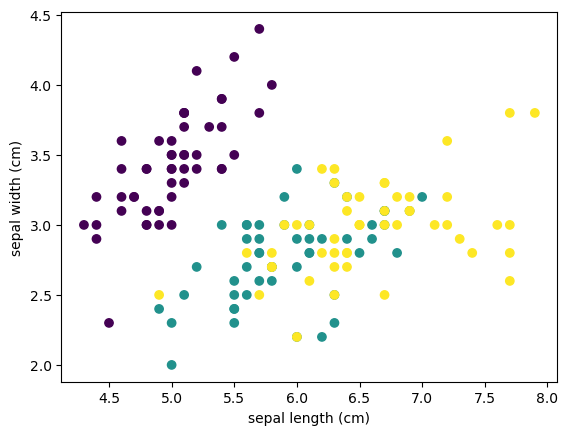

In [12]:
_, ax = plt.subplots()
scatter = ax.scatter(iris.data[:, 0], iris.data[:, 1], c=y)
ax.set(xlabel=iris.feature_names[0], ylabel=iris.feature_names[1])
plt.show()

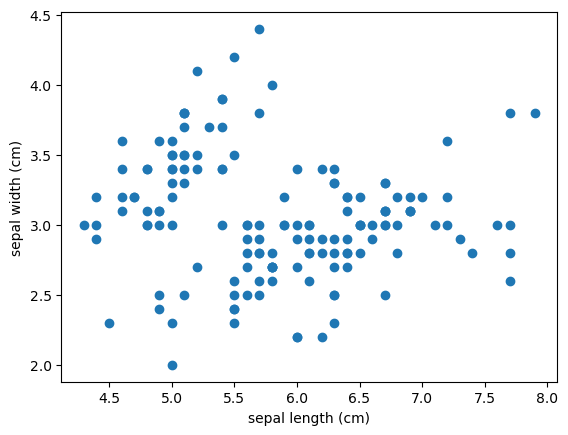

In [13]:
_, ax = plt.subplots()
scatter = ax.scatter(iris.data[:, 0], iris.data[:, 1])
ax.set(xlabel=iris.feature_names[0], ylabel=iris.feature_names[1])
plt.show()

### Modeling

Let's:
1. create a K-Means model with 6 components
2. check (visually) how it fits the actual 3 flower classes
3. experiment with other number of components
4. choose the optimal number of clusters, according to the "elbow" method

In [14]:
from sklearn.cluster import KMeans

In [27]:
X = X[:, :2]

In [28]:
### COMPLETE CODE:

model = KMeans(3, max_iter=100, n_init='auto', random_state=RANDOM_SEED).fit(X)

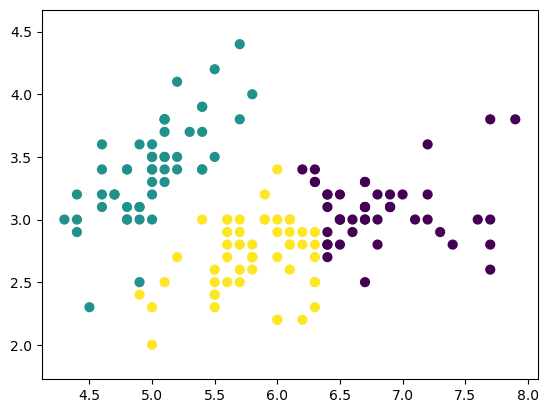

In [29]:
plot_clusters(model, X)

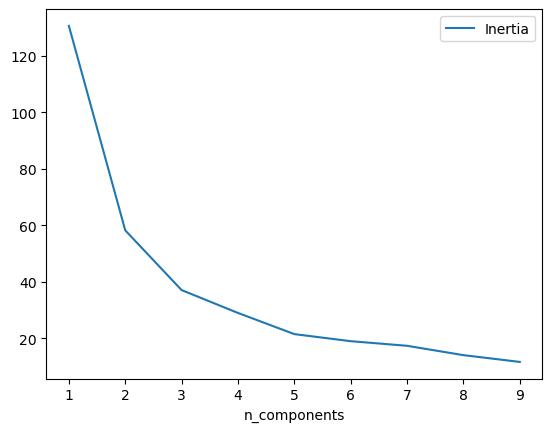

In [30]:
n_components = np.arange(1, 10)
models = [KMeans(n, max_iter=100, n_init='auto', random_state=RANDOM_SEED).fit(X)
          for n in n_components]

plt.plot(n_components, [m.inertia_ for m in models], label='Inertia')
plt.legend(loc='best')
plt.xlabel('n_components');

In [ ]:
### WHAT WOULD BE YOUR DECISION OF NR. OF CLUSTERS?


In [35]:
### Create a Agglomerative clustering model with your selection of (number of) clusters
### YOUR CODE HERE:

from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(3).fit(X)

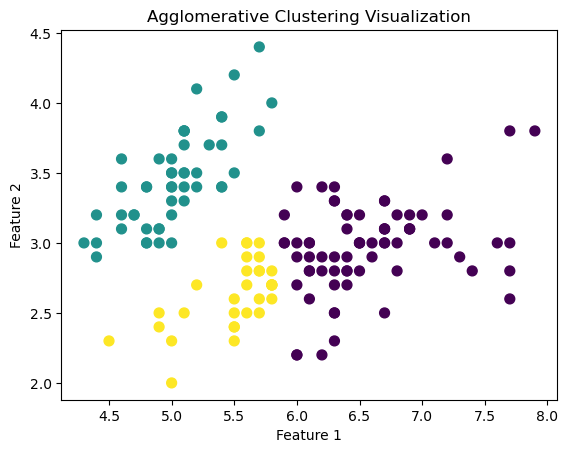

In [36]:
# Plot the clusters
plt.scatter(X[:, 0], X[:, 1], c=model.labels_, cmap='viridis', s=50)
plt.title("Agglomerative Clustering Visualization")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

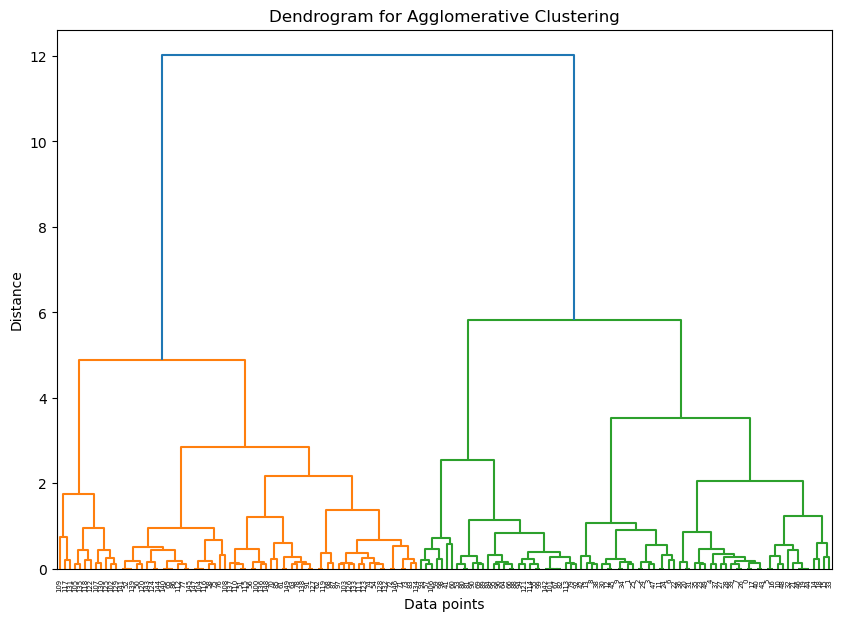

In [37]:
# Plot (equivalent) dendrogram 
Z = linkage(X, method='ward')  # Using the same linkage method as in AgglomerativeClustering

plt.figure(figsize=(10, 7))
dendrogram(Z)
plt.title("Dendrogram for Agglomerative Clustering")
plt.xlabel("Data points")
plt.ylabel("Distance")
plt.show()